In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as sla

#np.set_printoptions(precision=6, suppress=True)

In [2]:
def make_K_matrix(L, hopping):
    """Return the nearest-neighbour square-lattice hopping matrix with PBC."""
    if L < 3:
        raise ValueError("Use L >= 3; L=2 has duplicated periodic neighbours.")

    number_sites = L * L
    K_matrix = np.zeros((number_sites, number_sites), dtype=float)

    def site_index(x, y):
        return (x % L) + L * (y % L)

    for y in range(L):
        for x in range(L):
            i = site_index(x, y)
            # Right and upper bonds generate every undirected bond once.
            for j in (site_index(x + 1, y), site_index(x, y + 1)):
                K_matrix[i, j] = -hopping
                K_matrix[j, i] = -hopping

    return K_matrix


In [3]:
def make_exact_K_propagators(K_matrix, delta_tau):
    """Return the exact exp(-dt K) propagator and its inverse."""
    exp_minus_dtau_K = sla.expm(-delta_tau * K_matrix)
    exp_plus_dtau_K = sla.expm(+delta_tau * K_matrix)
    return exp_minus_dtau_K, exp_plus_dtau_K


def make_checkerboard_family_propagator(L, hopping, delta_tau, offset):
    """Return exp(-dt K_family) for one family of disjoint plaquettes."""
    if L < 4 or L % 2 != 0:
        raise ValueError("The plaquette checkerboard requires an even L >= 4.")
    if offset not in (0, 1):
        raise ValueError("offset must be 0 or 1.")

    # Exact exponential of the four-site hopping ring in one plaquette.
    c2 = np.cosh(2.0 * delta_tau * hopping)
    s2 = np.sinh(2.0 * delta_tau * hopping)
    same_site = 0.5 * (c2 + 1.0)
    edge = 0.5 * s2
    opposite_corner = 0.5 * (c2 - 1.0)
    plaquette_exp = np.array([
        [same_site, edge, opposite_corner, edge],
        [edge, same_site, edge, opposite_corner],
        [opposite_corner, edge, same_site, edge],
        [edge, opposite_corner, edge, same_site],
    ])

    number_sites = L * L
    family_exp = np.zeros((number_sites, number_sites), dtype=float)

    for y in range(offset, L, 2):
        for x in range(offset, L, 2):
            plaquette_sites = [
                x + y * L,
                ((x + 1) % L) + y * L,
                ((x + 1) % L) + ((y + 1) % L) * L,
                x + ((y + 1) % L) * L,
            ]
            family_exp[np.ix_(plaquette_sites, plaquette_sites)] = plaquette_exp

    return family_exp


def make_checkerboard_K_propagators(L, hopping, delta_tau):
    """Return checkerboard exp(-dt K) and its exact reverse-order inverse."""
    family_A_minus = make_checkerboard_family_propagator(
        L, hopping, +delta_tau, offset=0
    )
    family_B_minus = make_checkerboard_family_propagator(
        L, hopping, +delta_tau, offset=1
    )
    family_A_plus = make_checkerboard_family_propagator(
        L, hopping, -delta_tau, offset=0
    )
    family_B_plus = make_checkerboard_family_propagator(
        L, hopping, -delta_tau, offset=1
    )

    exp_minus_dtau_K = family_A_minus @ family_B_minus
    exp_plus_dtau_K = family_B_plus @ family_A_plus
    return exp_minus_dtau_K, exp_plus_dtau_K


In [4]:
def build_B_matrix(slice_index, spin, auxiliary_field, alpha, exp_minus_dtau_K):
    """Construct B_l^sigma = V_l^sigma exp(-dt K)."""
    potential = np.exp(spin * alpha * auxiliary_field[:, slice_index])
    return potential[:, None] * exp_minus_dtau_K


def build_B_inverse(slice_index, spin, auxiliary_field, alpha, exp_plus_dtau_K):
    """Construct (B_l^sigma)^(-1) = exp(+dt K) (V_l^sigma)^(-1)."""
    inverse_potential = np.exp(-spin * alpha * auxiliary_field[:, slice_index])
    return exp_plus_dtau_K * inverse_potential[None, :]


def cyclic_B_matrices(tau, spin, auxiliary_field, alpha, exp_minus_dtau_K):
    """Return the cyclic chronological B list defining the equal-time G(tau)."""
    number_slices = auxiliary_field.shape[1]
    cyclic_order = list(range(tau, number_slices)) + list(range(0, tau))
    return [
        build_B_matrix(l, spin, auxiliary_field, alpha, exp_minus_dtau_K)
        for l in cyclic_order
    ]


def form_B_blocks(B_matrices, block_size):
    """Group chronological slice matrices into short left-multiplied blocks."""
    matrix_size = B_matrices[0].shape[0]
    blocks = []
    for start in range(0, len(B_matrices), block_size):
        block = np.eye(matrix_size)
        for B_matrix in B_matrices[start:start + block_size]:
            block = B_matrix @ block
        blocks.append(block)
    return blocks


In [5]:
def svd_factor_B_product(B_matrices, block_size):
    """Compute U, singular values, Vh for the full left product of B matrices."""
    B_blocks = form_B_blocks(B_matrices, block_size)
    U, singular_values, Vh = np.linalg.svd(B_blocks[0], full_matrices=False)

    for B_block in B_blocks[1:]:
        # First SVD treats the new well-conditioned block and the old U.
        U_outer, outer_values, Vh_outer = np.linalg.svd(
            B_block @ U, full_matrices=False
        )

        # Second SVD combines the new scales with all accumulated old scales.
        inner_matrix = (
            outer_values[:, None] * Vh_outer
        ) * singular_values[None, :]
        U_inner, singular_values, Vh_inner = np.linalg.svd(
            inner_matrix, full_matrices=False
        )

        U = U_outer @ U_inner
        Vh = Vh_inner @ Vh

    return U, singular_values, Vh


def svd_green_from_factors(U, singular_values, Vh):
    """Stably calculate G=(I+U diag(d) Vh)^(-1) by splitting large scales."""
    large_values = np.maximum(singular_values, 1.0)
    small_values = np.minimum(singular_values, 1.0)

    right_hand_side = (1.0 / large_values)[:, None] * U.T
    core_matrix = right_hand_side + small_values[:, None] * Vh
    return np.linalg.solve(core_matrix, right_hand_side)


def recompute_G_svd(tau, spin, auxiliary_field, alpha,
                    exp_minus_dtau_K, block_size):
    """Reconstruct the equal-time Green function G^sigma(tau) from scratch."""
    B_matrices = cyclic_B_matrices(
        tau, spin, auxiliary_field, alpha, exp_minus_dtau_K
    )
    U, singular_values, Vh = svd_factor_B_product(B_matrices, block_size)
    return svd_green_from_factors(U, singular_values, Vh)


# Fast Update

In [6]:
def update_auxiliary_slice(G_up, G_dn, auxiliary_field, slice_index, alpha, rng):
    """Attempt every local HS-field flip at one slice using Sherman-Morrison."""
    number_sites = auxiliary_field.shape[0]
    accepted = 0

    for site in range(number_sites):
        old_field = auxiliary_field[site, slice_index]
        field_change = -2 * old_field

        delta_up = np.expm1(+alpha * field_change)
        delta_dn = np.expm1(-alpha * field_change)
        ratio_up = 1.0 + delta_up * (1.0 - G_up[site, site])
        ratio_dn = 1.0 + delta_dn * (1.0 - G_dn[site, site])
        determinant_ratio = ratio_up * ratio_dn

        if not np.isfinite(determinant_ratio):
            raise FloatingPointError("Non-finite determinant ratio encountered.")
        
        # Metropolis acceptance step
        if rng.random() < min(1.0, abs(determinant_ratio)):
            auxiliary_field[site, slice_index] = -old_field
            row_up = -G_up[site, :].copy()
            row_up[site] += 1.0
            column_up = G_up[:, site].copy()
            G_up -= (delta_up / ratio_up) * np.outer(column_up, row_up)

            row_dn = -G_dn[site, :].copy()
            row_dn[site] += 1.0
            column_dn = G_dn[:, site].copy()
            G_dn -= (delta_dn / ratio_dn) * np.outer(column_dn, row_dn)
            accepted += 1

    return G_up, G_dn, accepted


def measure_equal_time_observables(G_up, G_dn):
    """Return density, double occupancy, and S(pi,pi) for the current field."""
    number_sites = G_up.shape[0]
    L = int(round(np.sqrt(number_sites)))
    if L * L != number_sites:
        raise ValueError("S(pi,pi) requires a square L-by-L lattice.")

    density_up = 1.0 - np.diag(G_up)
    density_dn = 1.0 - np.diag(G_dn)
    density = np.mean(density_up + density_dn)
    double_occupancy = np.mean(density_up * density_dn)

    magnetization_z = density_up - density_dn
    connected_up = np.diag(np.diag(G_up)) - G_up.T * G_up
    connected_dn = np.diag(np.diag(G_dn)) - G_dn.T * G_dn
    spin_correlation = 0.25 * (
        np.outer(magnetization_z, magnetization_z)
        + connected_up
        + connected_dn
    )

    x = np.arange(number_sites) % L
    y = np.arange(number_sites) // L
    staggered_phase = (-1.0) ** (x + y)
    phase_matrix = np.outer(staggered_phase, staggered_phase)
    S_pi_pi = np.real(np.sum(phase_matrix * spin_correlation)) / number_sites

    return density, double_occupancy, S_pi_pi


In [7]:
def run_dqmc_sweeps(number_sites, number_slices, interaction, delta_tau,
                    exp_minus_dtau_K, exp_plus_dtau_K,
                    warmup_sweeps=500, measurement_sweeps=2000,
                    safe_interval=5, seed=1234):
    """Run stabilized forward-and-reverse DQMC sweeps at half filling."""
    if safe_interval < 1:
        raise ValueError("safe_interval must be positive.")

    rng = np.random.default_rng(seed)
    alpha = np.arccosh(np.exp(0.5 * interaction * delta_tau))
    auxiliary_field = rng.choice((-1, 1), size=(number_sites, number_slices))

    G_up = recompute_G_svd(
        0, +1, auxiliary_field, alpha, exp_minus_dtau_K, safe_interval
    )
    G_dn = recompute_G_svd(
        0, -1, auxiliary_field, alpha, exp_minus_dtau_K, safe_interval
    )

    density_measurements = []
    double_occupancy_measurements = []
    sq_measurements = []
    accepted_updates = 0
    attempted_updates = 0

    total_sweeps = warmup_sweeps + measurement_sweeps
    for sweep in range(total_sweeps):
        measure_this_sweep = sweep >= warmup_sweeps
        density_sum = 0.0
        double_occupancy_sum = 0.0
        sq_sum = 0.0

        # Forward pass: wrap with the old B_l, then update S[:, l].
        for l in range(number_slices):
            B_up = build_B_matrix(l, +1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_up = build_B_inverse(l, +1, auxiliary_field, alpha, exp_plus_dtau_K)
            B_dn = build_B_matrix(l, -1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_dn = build_B_inverse(l, -1, auxiliary_field, alpha, exp_plus_dtau_K)

            G_up = B_up @ G_up @ B_inv_up
            G_dn = B_dn @ G_dn @ B_inv_dn

            G_up, G_dn, accepted = update_auxiliary_slice(
                G_up, G_dn, auxiliary_field, l, alpha, rng
            )
            accepted_updates += accepted
            attempted_updates += number_sites

            # The current boundary is tau=l+1.
            if (l + 1) % safe_interval == 0:
                tau = l + 1
                G_up = recompute_G_svd(
                    tau, +1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )
                G_dn = recompute_G_svd(
                    tau, -1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )

            if measure_this_sweep:
                density, double_occupancy, S_pi_pi = measure_equal_time_observables(
                    G_up, G_dn
                )
                density_sum += density
                double_occupancy_sum += double_occupancy
                sq_sum += S_pi_pi

        # Reverse pass: update at G(l+1), then wrap backward with updated B_l.
        for l in range(number_slices - 1, -1, -1):
            G_up, G_dn, accepted = update_auxiliary_slice(
                G_up, G_dn, auxiliary_field, l, alpha, rng
            )
            accepted_updates += accepted
            attempted_updates += number_sites

            B_up = build_B_matrix(l, +1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_up = build_B_inverse(l, +1, auxiliary_field, alpha, exp_plus_dtau_K)
            B_dn = build_B_matrix(l, -1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_dn = build_B_inverse(l, -1, auxiliary_field, alpha, exp_plus_dtau_K)

            G_up = B_inv_up @ G_up @ B_up
            G_dn = B_inv_dn @ G_dn @ B_dn

            # The current boundary is tau=l.
            if l % safe_interval == 0:
                G_up = recompute_G_svd(
                    l, +1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )
                G_dn = recompute_G_svd(
                    l, -1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )

        if measure_this_sweep:
            density_measurements.append(density_sum / number_slices)
            double_occupancy_measurements.append(double_occupancy_sum / number_slices)
            sq_measurements.append(sq_sum / number_slices)

    density_measurements = np.asarray(density_measurements)
    double_occupancy_measurements = np.asarray(double_occupancy_measurements)
    sq_measurements = np.asarray(sq_measurements)

    def mean_and_naive_sem(samples):
        if len(samples) < 2:
            return float(np.mean(samples)), np.nan
        return float(np.mean(samples)), float(np.std(samples, ddof=1) / np.sqrt(len(samples)))

    return {
        "density": mean_and_naive_sem(density_measurements),
        "double_occupancy": mean_and_naive_sem(double_occupancy_measurements),
        "S_pi_pi": mean_and_naive_sem(sq_measurements),
        "density_measurements": density_measurements,
        "double_occupancy_measurements": double_occupancy_measurements,
        "sq_measurements": sq_measurements,
        "acceptance_rate": accepted_updates / attempted_updates,
        "final_auxiliary_field": auxiliary_field,
    }


In [8]:
L = 4
number_sites = L * L
hopping = 1.0
beta = 4.0
delta_tau = 0.1
number_slices = int(round(beta / delta_tau))
safe_interval = 5

U_values = [1.0]
warmup_sweeps = 500
measurement_sweeps = 2000
kinetic_method = "checkerboard"       # Change to "checkerboard" when desired.

K_matrix = make_K_matrix(L, hopping)
if kinetic_method == "exact":
    exp_minus_dtau_K, exp_plus_dtau_K = make_exact_K_propagators(K_matrix, delta_tau)
elif kinetic_method == "checkerboard":
    exp_minus_dtau_K, exp_plus_dtau_K = make_checkerboard_K_propagators(L, hopping, delta_tau)
else:
    raise ValueError("kinetic_method must be 'exact' or 'checkerboard'.")

inverse_residual = np.linalg.norm(exp_minus_dtau_K @ exp_plus_dtau_K - np.eye(number_sites))
print(f"Kinetic method: {kinetic_method}")
print(f"Inverse residual: {inverse_residual:.3e}")

Kinetic method: checkerboard
Inverse residual: 1.785e-15


In [9]:
dqmc_results = {}
sq_measurements_list = []

for U in U_values:
    result = run_dqmc_sweeps(
        number_sites=number_sites,
        number_slices=number_slices,
        interaction=U,
        delta_tau=delta_tau,
        exp_minus_dtau_K=exp_minus_dtau_K,
        exp_plus_dtau_K=exp_plus_dtau_K,
        warmup_sweeps=warmup_sweeps,
        measurement_sweeps=measurement_sweeps,
        safe_interval=safe_interval,
        seed=1234 + int(100 * U),
    )
    dqmc_results[U] = result
    sq_measurements_list.append(result["sq_measurements"])

    print(
        f"U={U:3.1f}: density={result['density'][0]:.6f}, "
        f"double_occ={result['double_occupancy'][0]:.6f}, "
        f"S(pi,pi)={result['S_pi_pi'][0]:.6f}, "
        f"acceptance={result['acceptance_rate']:.4f}"
    )

U=1.0: density=1.000000, double_occ=0.216428, S(pi,pi)=0.255532, acceptance=0.9123


# Delay Update

In [10]:
def logical_diagonal(G, pending, site):
    """G[site, site] including accepted but unflushed updates."""
    return G[site, site] + sum(
        s * u[site] * v[site] for u, s, v in pending
    )


def logical_column(G, pending, site):
    column = G[:, site].copy()
    for u, s, v in pending:
        column += s * u * v[site]
    return column


def logical_row(G, pending, site):
    row = G[site, :].copy()
    for u, s, v in pending:
        row += s * u[site] * v
    return row


def record_accepted(G, pending, site, delta, ratio):
    """Store the correction using the logical G before this flip."""
    u = logical_column(G, pending, site)
    v = logical_row(G, pending, site)
    v[site] -= 1.0

    pending.append((u, delta / ratio, v))


def flush_updates(G, pending):
    """Apply all pending corrections to G in one matrix multiplication."""
    if not pending:
        return

    U = np.column_stack([u for u, s, v in pending])
    s = np.array([s for u, s, v in pending])
    V = np.stack([v for u, s, v in pending])

    G[...] += (U * s[None, :]) @ V
    pending.clear()


def update_auxiliary_slice_delayed(
    G_up, G_dn, auxiliary_field, slice_index, alpha, rng, batch_size=8
):
    """Attempt local flips, batching accepted Green-function corrections."""
    if batch_size < 1:
        raise ValueError("batch_size must be positive.")

    number_sites = auxiliary_field.shape[0]
    pending_up = []
    pending_dn = []
    accepted = 0

    for site in range(number_sites):
        old_field = auxiliary_field[site, slice_index]
        field_change = -2 * old_field

        delta_up = np.expm1(+alpha * field_change)
        delta_dn = np.expm1(-alpha * field_change)
        ratio_up = 1.0 + delta_up * (1.0 - logical_diagonal(G_up, pending_up, site))
        ratio_dn = 1.0 + delta_dn * (1.0 - logical_diagonal(G_dn, pending_dn, site))
        determinant_ratio = ratio_up * ratio_dn

        if not np.isfinite(determinant_ratio):
            raise FloatingPointError("Non-finite determinant ratio encountered.")

        # Both factors use the logical Green functions before this flip.
        if rng.random() < min(1.0, abs(determinant_ratio)):
            record_accepted(G_up, pending_up, site, delta_up, ratio_up)
            record_accepted(G_dn, pending_dn, site, delta_dn, ratio_dn)
            auxiliary_field[site, slice_index] = -old_field
            accepted += 1

            if len(pending_up) == batch_size:
                flush_updates(G_up, pending_up)
                flush_updates(G_dn, pending_dn)

    # Propagation, stabilisation and measurement all need materialised G.
    flush_updates(G_up, pending_up)
    flush_updates(G_dn, pending_dn)
    return G_up, G_dn, accepted


def run_dqmc_sweeps_delayed(number_sites, number_slices, interaction, delta_tau,
                    exp_minus_dtau_K, exp_plus_dtau_K,
                    warmup_sweeps=500, measurement_sweeps=2000,
                    safe_interval=5, seed=1234, batch_size=8):
    """Run stabilized DQMC sweeps with batched local Green updates."""
    if safe_interval < 1:
        raise ValueError("safe_interval must be positive.")
    if batch_size < 1:
        raise ValueError("batch_size must be positive.")

    rng = np.random.default_rng(seed)
    alpha = np.arccosh(np.exp(0.5 * interaction * delta_tau))
    auxiliary_field = rng.choice((-1, 1), size=(number_sites, number_slices))

    G_up = recompute_G_svd(
        0, +1, auxiliary_field, alpha, exp_minus_dtau_K, safe_interval
    )
    G_dn = recompute_G_svd(
        0, -1, auxiliary_field, alpha, exp_minus_dtau_K, safe_interval
    )

    density_measurements = []
    double_occupancy_measurements = []
    sq_measurements = []
    accepted_updates = 0
    attempted_updates = 0

    total_sweeps = warmup_sweeps + measurement_sweeps
    for sweep in range(total_sweeps):
        measure_this_sweep = sweep >= warmup_sweeps
        density_sum = 0.0
        double_occupancy_sum = 0.0
        sq_sum = 0.0

        # Forward pass: wrap with the old B_l, then update S[:, l].
        for l in range(number_slices):
            B_up = build_B_matrix(l, +1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_up = build_B_inverse(l, +1, auxiliary_field, alpha, exp_plus_dtau_K)
            B_dn = build_B_matrix(l, -1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_dn = build_B_inverse(l, -1, auxiliary_field, alpha, exp_plus_dtau_K)

            G_up = B_up @ G_up @ B_inv_up
            G_dn = B_dn @ G_dn @ B_inv_dn

            G_up, G_dn, accepted = update_auxiliary_slice_delayed(
                G_up, G_dn, auxiliary_field, l, alpha, rng, batch_size=batch_size
            )
            accepted_updates += accepted
            attempted_updates += number_sites

            # The current boundary is tau=l+1.
            if (l + 1) % safe_interval == 0:
                tau = l + 1
                G_up = recompute_G_svd(
                    tau, +1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )
                G_dn = recompute_G_svd(
                    tau, -1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )

            if measure_this_sweep:
                density, double_occupancy, S_pi_pi = measure_equal_time_observables(
                    G_up, G_dn
                )
                density_sum += density
                double_occupancy_sum += double_occupancy
                sq_sum += S_pi_pi

        # Reverse pass: update at G(l+1), then wrap backward with updated B_l.
        for l in range(number_slices - 1, -1, -1):
            G_up, G_dn, accepted = update_auxiliary_slice_delayed(
                G_up, G_dn, auxiliary_field, l, alpha, rng, batch_size=batch_size
            )
            accepted_updates += accepted
            attempted_updates += number_sites

            B_up = build_B_matrix(l, +1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_up = build_B_inverse(l, +1, auxiliary_field, alpha, exp_plus_dtau_K)
            B_dn = build_B_matrix(l, -1, auxiliary_field, alpha, exp_minus_dtau_K)
            B_inv_dn = build_B_inverse(l, -1, auxiliary_field, alpha, exp_plus_dtau_K)

            G_up = B_inv_up @ G_up @ B_up
            G_dn = B_inv_dn @ G_dn @ B_dn

            # The current boundary is tau=l.
            if l % safe_interval == 0:
                G_up = recompute_G_svd(
                    l, +1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )
                G_dn = recompute_G_svd(
                    l, -1, auxiliary_field, alpha,
                    exp_minus_dtau_K, safe_interval
                )

        if measure_this_sweep:
            density_measurements.append(density_sum / number_slices)
            double_occupancy_measurements.append(double_occupancy_sum / number_slices)
            sq_measurements.append(sq_sum / number_slices)

    density_measurements = np.asarray(density_measurements)
    double_occupancy_measurements = np.asarray(double_occupancy_measurements)
    sq_measurements = np.asarray(sq_measurements)

    def mean_and_naive_sem(samples):
        if len(samples) < 2:
            return float(np.mean(samples)), np.nan
        return float(np.mean(samples)), float(np.std(samples, ddof=1) / np.sqrt(len(samples)))

    return {
        "density": mean_and_naive_sem(density_measurements),
        "double_occupancy": mean_and_naive_sem(double_occupancy_measurements),
        "S_pi_pi": mean_and_naive_sem(sq_measurements),
        "density_measurements": density_measurements,
        "double_occupancy_measurements": double_occupancy_measurements,
        "sq_measurements": sq_measurements,
        "acceptance_rate": accepted_updates / attempted_updates,
        "final_auxiliary_field": auxiliary_field,
    }


# Reuse the fast-update cell's parameters and seeds for a direct comparison.
delay_batch_size = 2
delayed_dqmc_results = {}

for U in U_values:
    delayed_result = run_dqmc_sweeps_delayed(
        number_sites=number_sites,
        number_slices=number_slices,
        interaction=U,
        delta_tau=delta_tau,
        exp_minus_dtau_K=exp_minus_dtau_K,
        exp_plus_dtau_K=exp_plus_dtau_K,
        warmup_sweeps=warmup_sweeps,
        measurement_sweeps=measurement_sweeps,
        safe_interval=safe_interval,
        seed=1234 + int(100 * U),
        batch_size=delay_batch_size,
    )
    delayed_dqmc_results[U] = delayed_result
    fast_result = dqmc_results[U]

    print(
        f"U={U:3.1f}, batch={delay_batch_size}: "
        f"density={delayed_result['density'][0]:.6f}, "
        f"double_occ={delayed_result['double_occupancy'][0]:.6f}, "
        f"S(pi,pi)={delayed_result['S_pi_pi'][0]:.6f}, "
        f"acceptance={delayed_result['acceptance_rate']:.4f}"
    )
    print(
        "  Matches fast update: field=", np.array_equal(
            delayed_result["final_auxiliary_field"],
            fast_result["final_auxiliary_field"],
        ),
        ", density series=", np.allclose(
            delayed_result["density_measurements"],
            fast_result["density_measurements"], rtol=1e-9, atol=1e-9,
        ),
        ", double-occupancy series=", np.allclose(
            delayed_result["double_occupancy_measurements"],
            fast_result["double_occupancy_measurements"], rtol=1e-9, atol=1e-9,
        ),
        ", S(pi,pi) series=", np.allclose(
            delayed_result["sq_measurements"],
            fast_result["sq_measurements"], rtol=1e-9, atol=1e-9,
        ),
    )


U=1.0, batch=2: density=1.000000, double_occ=0.216428, S(pi,pi)=0.255532, acceptance=0.9123
  Matches fast update: field= True , density series= True , double-occupancy series= True , S(pi,pi) series= True


## Small-size benchmark: fast versus delayed updates

We want to check that batching Green-function corrections preserves the sampled observables, and measure the wall-clock cost of the **same amount of Monte Carlo work**.

Run the following three code cells directly, even in a fresh kernel. The first cell loads only imports and function definitions from the original cells above; it does not run their longer simulations. Requires the notebook's NumPy/SciPy/Matplotlib environment and `threadpoolctl` (available in the Anaconda base environment).

Results stay in `benchmark_payload` in the current kernel, and figures are displayed inline. No results folder, JSON file or PNG file is created. After restarting the kernel, rerun the setup and benchmark cells before plotting; saving the notebook preserves its displayed outputs, but not the in-memory raw data.

### Conditions and interpretation

- Square lattices $L=4,6,8$, so $N=L^2=16,36,64$ sites, at half filling.
- $t=1$, $U/t=4$, $\beta t=2$, hence $T/t=0.5$ with $k_B=1$.
- $\Delta\tau t=0.1$, giving $M=\beta/\Delta\tau=20$ time slices. Reducing $\beta$ shortens the run without increasing the time-step discretisation error.
- 10 warm-up and 30 measurement sweeps per run; here one sweep contains a forward **and** reverse pass.
- Same checkerboard propagators, stabilisation interval 5, seeds and sweep counts for both methods; delayed batch size 8 accepted flips.
- Three independent seeds, paired between methods. Alternate execution order, pre-run both methods without timing, and limit BLAS to one thread.

Each timer includes initial Green-function reconstruction, all sweeps, stabilisation, measurements and returned statistics. Imports, kinetic-propagator construction, the untimed pre-run, printing and plotting are excluded. Results describe this machine and software environment.

For agreement, compare the entire per-sweep density, double-occupancy and $S(\pi,\pi)$ series, acceptance rates and final auxiliary fields. Matching means alone is a weaker check. Floating-point changes can eventually cause paired trajectories to diverge, so a failed trajectory check needs investigation rather than automatically proving the physics differs.

These short chains are intended for implementation and timing comparisons. They do not establish equilibration, precise thermodynamic estimates or asymptotic time scaling. Observable error bars below are the SEM across three independent run means, not the existing runner's naive per-sweep SEM.


In [ ]:
from pathlib import Path
from time import perf_counter
from datetime import datetime, timezone
import ast
import json
import platform
import sys

import numpy as np
import scipy
import matplotlib.pyplot as plt
from threadpoolctl import threadpool_limits, threadpool_info

# Load definitions only: skip the original parameter cells and simulation calls.
benchmark_notebook_path = Path('Delay Update.ipynb')
if not benchmark_notebook_path.is_file():
    benchmark_notebook_path = Path('delay_update') / 'Delay Update.ipynb'
benchmark_notebook_path = benchmark_notebook_path.resolve()
benchmark_source = json.loads(benchmark_notebook_path.read_text(encoding='utf-8'))
benchmark_functions = {}
for cell in benchmark_source['cells']:
    if cell.get('metadata', {}).get('delay_benchmark'):
        break
    if cell['cell_type'] != 'code':
        continue
    tree = ast.parse(''.join(cell['source']))
    tree.body = [node for node in tree.body
                 if isinstance(node, (ast.Import, ast.ImportFrom, ast.FunctionDef))]
    exec(compile(tree, str(benchmark_notebook_path), 'exec'), benchmark_functions)

benchmark_config = {
    'L_values': [4, 6, 8, 10, 12],
    'hopping': 1.0,
    'interaction': 4.0,
    'beta': 2.0,
    'delta_tau': 0.1,
    'warmup_sweeps': 10,
    'measurement_sweeps': 30,
    'safe_interval': 5,
    'batch_size': 2,
    'seeds': [20261005, 20261006, 20261007],
    'blas_threads': 1,
    'kinetic_method': 'checkerboard',
    'comparison_rtol': 1e-8,
    'comparison_atol': 1e-10,
}
benchmark_number_slices = int(round(benchmark_config['beta'] / benchmark_config['delta_tau']))
assert np.isclose(benchmark_number_slices * benchmark_config['delta_tau'], benchmark_config['beta'])
print(f"L={benchmark_config['L_values']}; beta={benchmark_config['beta']}; "
      f"T={1 / benchmark_config['beta']}; time slices={benchmark_number_slices}")
print('Timed sweeps per run:', benchmark_config['warmup_sweeps'] + benchmark_config['measurement_sweeps'])


L=[4, 6, 8, 10, 12]; beta=2.0; T=0.5; time slices=20
Timed sweeps per run: 40


In [12]:
benchmark_records = []
benchmark_checks = []
benchmark_series_keys = ('density_measurements', 'double_occupancy_measurements', 'sq_measurements')
benchmark_runners = {
    'fast': benchmark_functions['run_dqmc_sweeps'],
    'delayed': benchmark_functions['run_dqmc_sweeps_delayed'],
}

with threadpool_limits(limits=benchmark_config['blas_threads'], user_api='blas'):
    benchmark_environment = {
        'utc_time': datetime.now(timezone.utc).isoformat(),
        'python': sys.version,
        'executable': sys.executable,
        'platform': platform.platform(),
        'numpy': np.__version__,
        'scipy': scipy.__version__,
        'threadpools_during_timing': threadpool_info(),
    }
    for benchmark_L in benchmark_config['L_values']:
        minus, plus = benchmark_functions['make_checkerboard_K_propagators'](
            benchmark_L, benchmark_config['hopping'], benchmark_config['delta_tau']
        )
        common = dict(
            number_sites=benchmark_L ** 2,
            number_slices=benchmark_number_slices,
            interaction=benchmark_config['interaction'],
            delta_tau=benchmark_config['delta_tau'],
            exp_minus_dtau_K=minus,
            exp_plus_dtau_K=plus,
            warmup_sweeps=benchmark_config['warmup_sweeps'],
            measurement_sweeps=benchmark_config['measurement_sweeps'],
            safe_interval=benchmark_config['safe_interval'],
        )

        # Untimed pre-run at each size: initialise numerical-library code paths.
        pre_run = {**common, 'warmup_sweeps': 0, 'measurement_sweeps': 1, 'seed': 9876}
        benchmark_runners['fast'](**pre_run)
        benchmark_runners['delayed'](**pre_run, batch_size=benchmark_config['batch_size'])

        for repeat, benchmark_seed in enumerate(benchmark_config['seeds']):
            order = ('fast', 'delayed') if repeat % 2 == 0 else ('delayed', 'fast')
            paired_results = {}
            for method in order:
                kwargs = {**common, 'seed': benchmark_seed}
                if method == 'delayed':
                    kwargs['batch_size'] = benchmark_config['batch_size']
                started = perf_counter()
                result = benchmark_runners[method](**kwargs)
                elapsed = perf_counter() - started
                paired_results[method] = result
                benchmark_records.append({
                    'L': benchmark_L, 'N': benchmark_L ** 2,
                    'seed': benchmark_seed, 'method': method,
                    'seconds': elapsed,
                    'density': float(result['density'][0]),
                    'double_occupancy': float(result['double_occupancy'][0]),
                    'S_pi_pi': float(result['S_pi_pi'][0]),
                    'acceptance_rate': float(result['acceptance_rate']),
                    **{key: result[key].tolist() for key in benchmark_series_keys},
                    'final_auxiliary_field': result['final_auxiliary_field'].tolist(),
                })
                print(f"L={benchmark_L}, repeat={repeat + 1}, {method:7s}: "
                      f"{elapsed:.3f} s; D={result['double_occupancy'][0]:.8f}; "
                      f"S(pi,pi)={result['S_pi_pi'][0]:.8f}", flush=True)

            fast, delayed = paired_results['fast'], paired_results['delayed']
            check = {
                'L': benchmark_L, 'seed': benchmark_seed,
                'same_final_field': bool(np.array_equal(
                    fast['final_auxiliary_field'], delayed['final_auxiliary_field'])),
                'same_acceptance': fast['acceptance_rate'] == delayed['acceptance_rate'],
                'max_abs_series_difference': {
                    key: float(np.max(np.abs(fast[key] - delayed[key])))
                    for key in benchmark_series_keys
                },
                'series_close': all(np.allclose(
                    fast[key], delayed[key],
                    rtol=benchmark_config['comparison_rtol'],
                    atol=benchmark_config['comparison_atol']) for key in benchmark_series_keys),
                'max_density_deviation_from_one': max(
                    float(np.max(np.abs(result['density_measurements'] - 1)))
                    for result in (fast, delayed)),
            }
            benchmark_checks.append(check)

# Keep every run and its series in memory for plotting in this kernel.
benchmark_payload = dict(config=benchmark_config, environment=benchmark_environment,
                         records=benchmark_records, checks=benchmark_checks)
print('\n L   fast median [range] / s     delayed median [range] / s   speedup')
for benchmark_L in benchmark_config['L_values']:
    timings = {method: np.array([r['seconds'] for r in benchmark_records
                                if r['L'] == benchmark_L and r['method'] == method])
               for method in benchmark_runners}
    f, d = timings['fast'], timings['delayed']
    print(f'{benchmark_L:2d}   {np.median(f):7.3f} [{f.min():.3f}, {f.max():.3f}]'
          f'       {np.median(d):7.3f} [{d.min():.3f}, {d.max():.3f}]'
          f'       {np.median(f) / np.median(d):.3f}x')

benchmark_all_match = all(c['series_close'] and c['same_final_field'] and c['same_acceptance']
                          for c in benchmark_checks)
print('\nAll paired series, final fields and acceptance rates match:', benchmark_all_match)
for key in benchmark_series_keys:
    print(key, 'maximum paired absolute difference:',
          max(c['max_abs_series_difference'][key] for c in benchmark_checks))
if not benchmark_all_match:
    print('Inspect benchmark_checks before interpreting observable or timing comparisons.')


L=4, repeat=1, fast   : 0.883 s; D=0.12829546; S(pi,pi)=0.26701215
L=4, repeat=1, delayed: 1.169 s; D=0.12829546; S(pi,pi)=0.26701215
L=4, repeat=2, delayed: 1.209 s; D=0.12839314; S(pi,pi)=0.38743859
L=4, repeat=2, fast   : 0.874 s; D=0.12839314; S(pi,pi)=0.38743859
L=4, repeat=3, fast   : 0.883 s; D=0.12991513; S(pi,pi)=0.42891881
L=4, repeat=3, delayed: 1.674 s; D=0.12991513; S(pi,pi)=0.42891881
L=6, repeat=1, fast   : 5.339 s; D=0.13018729; S(pi,pi)=0.39030861
L=6, repeat=1, delayed: 5.147 s; D=0.13018729; S(pi,pi)=0.39030861
L=6, repeat=2, delayed: 5.117 s; D=0.13135602; S(pi,pi)=0.31567312
L=6, repeat=2, fast   : 4.017 s; D=0.13135602; S(pi,pi)=0.31567312
L=6, repeat=3, fast   : 4.104 s; D=0.13382409; S(pi,pi)=0.51684525
L=6, repeat=3, delayed: 4.898 s; D=0.13382409; S(pi,pi)=0.51684525
L=8, repeat=1, fast   : 9.336 s; D=0.13307477; S(pi,pi)=0.40065991
L=8, repeat=1, delayed: 11.167 s; D=0.13307477; S(pi,pi)=0.40065991
L=8, repeat=2, delayed: 10.973 s; D=0.13285275; S(pi,pi)=0.35

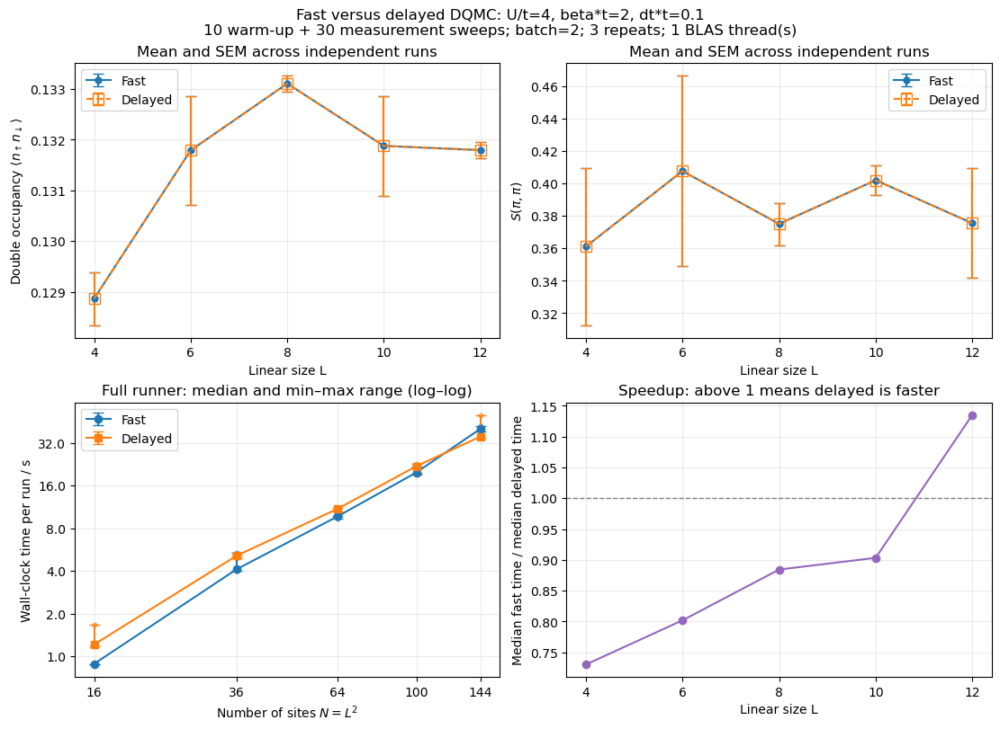

In [13]:
# Replot the results held in memory; no files are read or written.
if 'benchmark_payload' not in globals():
    raise RuntimeError('Run the benchmark setup and calculation cells before plotting.')
benchmark_plot_data = benchmark_payload
plot_config = benchmark_plot_data['config']
plot_records = benchmark_plot_data['records']
plot_L = np.array(plot_config['L_values'])
plot_N = plot_L ** 2
plot_colours = {'fast': 'tab:blue', 'delayed': 'tab:orange'}
plot_markers = {'fast': 'o', 'delayed': 's'}

fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for ax, quantity, label in zip(
    axes[0], ('double_occupancy', 'S_pi_pi'),
    (r'Double occupancy $\langle n_\uparrow n_\downarrow\rangle$', r'$S(\pi,\pi)$')
):
    for method in ('fast', 'delayed'):
        values = [np.array([r[quantity] for r in plot_records
                            if r['L'] == L and r['method'] == method]) for L in plot_L]
        means = np.array([v.mean() for v in values])
        sem = np.array([v.std(ddof=1) / np.sqrt(len(v)) if len(v) > 1 else 0.0 for v in values])
        ax.errorbar(plot_L, means, yerr=sem, label=method.capitalize(),
                    color=plot_colours[method], marker=plot_markers[method],
                    markerfacecolor='none' if method == 'delayed' else plot_colours[method],
                    markersize=8 if method == 'delayed' else 5,
                    linestyle='--' if method == 'delayed' else '-', capsize=4)
    ax.set(xlabel='Linear size L', ylabel=label, xticks=plot_L)
    ax.set_title('Mean and SEM across independent runs')
    ax.grid(alpha=0.25)
    ax.legend()

ax = axes[1, 0]
plot_medians = {}
for method in ('fast', 'delayed'):
    times = [np.array([r['seconds'] for r in plot_records
                       if r['L'] == L and r['method'] == method]) for L in plot_L]
    medians = np.array([v for v in map(np.median, times)])
    plot_medians[method] = medians
    ranges = np.array([[m - v.min() for m, v in zip(medians, times)],
                       [v.max() - m for m, v in zip(medians, times)]])
    ax.errorbar(plot_N, medians, yerr=ranges, label=method.capitalize(),
                color=plot_colours[method], marker=plot_markers[method], capsize=4)
    for N, values in zip(plot_N, times):
        ax.scatter(np.full(len(values), N), values, color=plot_colours[method], s=12, alpha=0.5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(plot_N, [str(N) for N in plot_N])
ax.minorticks_off()
ax.yaxis.set_major_locator(plt.matplotlib.ticker.LogLocator(base=2))
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set(xlabel=r'Number of sites $N=L^2$', ylabel='Wall-clock time per run / s',
       title='Full runner: median and min–max range (log–log)')
ax.grid(alpha=0.25)
ax.legend()

ax = axes[1, 1]
ax.plot(plot_L, plot_medians['fast'] / plot_medians['delayed'], 'o-', color='tab:purple')
ax.axhline(1.0, color='grey', linestyle='--', linewidth=1)
ax.set(xlabel='Linear size L', ylabel='Median fast time / median delayed time',
       title='Speedup: above 1 means delayed is faster', xticks=plot_L)
ax.grid(alpha=0.25)
fig.suptitle(
    f"Fast versus delayed DQMC: U/t={plot_config['interaction'] / plot_config['hopping']:g}, "
    f"beta*t={plot_config['beta'] * plot_config['hopping']:g}, "
    f"dt*t={plot_config['delta_tau'] * plot_config['hopping']:g}\n"
    f"{plot_config['warmup_sweeps']} warm-up + {plot_config['measurement_sweeps']} measurement sweeps; "
    f"batch={plot_config['batch_size']}; {len(plot_config['seeds'])} repeats; "
    f"{plot_config['blas_threads']} BLAS thread(s)"
)
plt.show()


### Reading the benchmark

The two observable curves should overlap when the paired trajectories agree. The full-series checks printed above test this more strictly than the plot. The observable bars describe variability between these short independent runs; increase warm-up and measurement sweeps and assess autocorrelation before drawing physical conclusions.

The runtime panel holds temperature, time step, sweep counts and stabilisation settings fixed while increasing $N=L^2$. Its bars show the observed timing range, not a confidence interval. The speedup is $t_{\mathrm{fast}}/t_{\mathrm{delayed}}$; values below one mean the delayed implementation took longer.

Small matrices can favour the immediate update: Python loops and logical row/column reconstruction can outweigh the benefit of batching. Both runners also pay for the same propagation, SVD stabilisation and measurements. This is an end-to-end benchmark, so it does not isolate the local-update kernel.

With fixed time slices and sweep counts, dense site updates and dense reconstruction can contribute costs of order $N^3$ (equivalently $L^6$), but these three small sizes do not determine an asymptotic exponent. Treat the measured curve as the practical scaling over this size range. To extend the experiment, change `benchmark_config` only and rerun the benchmark cells. Keep all other conditions identical between methods; benchmark other batch sizes separately.


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from threadpoolctl import threadpool_limits

# Settings for this timing experiment.
timing_L = 12
timing_seed = 20261005
number_pairs = 8                 # Even number: balances execution order.
batch_sizes = [2,4,8,16]                # Later change to [2, 4, 8, 16].

assert number_pairs >= 2 and number_pairs % 2 == 0

# Use the functions loaded by the existing benchmark setup cell.
fast_runner = benchmark_functions["run_dqmc_sweeps"]
delayed_runner = benchmark_functions["run_dqmc_sweeps_delayed"]
make_propagators = benchmark_functions["make_checkerboard_K_propagators"]

# Construct propagators outside the timer.
minus, plus = make_propagators(
    timing_L,
    benchmark_config["hopping"],
    benchmark_config["delta_tau"],
)

# Identical simulation inputs for every timed run.
common = dict(
    number_sites=timing_L**2,
    number_slices=benchmark_number_slices,
    interaction=benchmark_config["interaction"],
    delta_tau=benchmark_config["delta_tau"],
    exp_minus_dtau_K=minus,
    exp_plus_dtau_K=plus,
    warmup_sweeps=benchmark_config["warmup_sweeps"],
    measurement_sweeps=benchmark_config["measurement_sweeps"],
    safe_interval=benchmark_config["safe_interval"],
    seed=timing_seed,
)

timing_records = []

with threadpool_limits(
    limits=benchmark_config["blas_threads"],
    user_api="blas",
):
    # Untimed pre-runs initialise numerical-library code paths.
    pre_run = {
        **common,
        "warmup_sweeps": 0,
        "measurement_sweeps": 1,
    }
    fast_runner(**pre_run)
    for batch in batch_sizes:
        delayed_runner(**pre_run, batch_size=batch)

    for pair in range(number_pairs):
        # When testing several batches, rotate their execution order too.
        batch_order = (
            batch_sizes[pair % len(batch_sizes):]
            + batch_sizes[:pair % len(batch_sizes)]
        )

        for batch in batch_order:
            method_order = (
                ("fast", "delayed")
                if pair % 2 == 0
                else ("delayed", "fast")
            )

            results = {}
            seconds = {}

            for method in method_order:
                if method == "fast":
                    started = perf_counter()
                    result = fast_runner(**common)
                else:
                    started = perf_counter()
                    result = delayed_runner(**common, batch_size=batch)

                seconds[method] = perf_counter() - started
                results[method] = result

            # Verify that this timing pair performed matching calculations.
            series_match = all(
                np.allclose(
                    results["fast"][key],
                    results["delayed"][key],
                    rtol=benchmark_config["comparison_rtol"],
                    atol=benchmark_config["comparison_atol"],
                )
                for key in (
                    "density_measurements",
                    "double_occupancy_measurements",
                    "sq_measurements",
                )
            )

            fields_match = np.array_equal(
                results["fast"]["final_auxiliary_field"],
                results["delayed"]["final_auxiliary_field"],
            )

            acceptance_match = (
                results["fast"]["acceptance_rate"]
                == results["delayed"]["acceptance_rate"]
            )

            if not (series_match and fields_match and acceptance_match):
                raise RuntimeError(
                    f"Agreement check failed: pair {pair + 1}, batch {batch}"
                )

            speedup = seconds["fast"] / seconds["delayed"]

            timing_records.append({
                "pair": pair + 1,
                "batch": batch,
                "fast_seconds": seconds["fast"],
                "delayed_seconds": seconds["delayed"],
                "speedup": speedup,
            })

            print(
                f"Pair {pair + 1}/{number_pairs}, batch={batch}: "
                f"fast={seconds['fast']:.3f} s, "
                f"delayed={seconds['delayed']:.3f} s, "
                f"fast/delayed={speedup:.3f}",
                flush=True,
            )

# Show every paired ratio, rather than only a ratio of median times.
fig, ax = plt.subplots(figsize=(8, 4), constrained_layout=True)

for batch in batch_sizes:
    records = [r for r in timing_records if r["batch"] == batch]
    ratios = np.array([r["speedup"] for r in records])

    ax.plot(
        [r["pair"] for r in records],
        ratios,
        "o-",
        label=f"Batch {batch}",
    )

    print(
        f"\nBatch {batch}: "
        f"median paired speedup={np.median(ratios):.3f}; "
        f"range={ratios.min():.3f}–{ratios.max():.3f}; "
        f"delayed faster in {np.sum(ratios > 1)}/{len(ratios)} pairs"
    )

ax.axhline(1, color="grey", linestyle="--")
ax.set(
    xlabel="Timing pair",
    ylabel="Fast time / delayed time",
    title=f"Repeated identical calculation: L={timing_L}, seed={timing_seed}",
    xticks=range(1, number_pairs + 1),
)
ax.grid(alpha=0.25)
ax.legend()
plt.show()

Pair 1/8, batch=2: fast=38.364 s, delayed=32.957 s, fast/delayed=1.164
Pair 1/8, batch=4: fast=36.326 s, delayed=33.595 s, fast/delayed=1.081
Pair 1/8, batch=8: fast=36.954 s, delayed=36.108 s, fast/delayed=1.023
Pair 1/8, batch=16: fast=36.351 s, delayed=44.822 s, fast/delayed=0.811
Pair 2/8, batch=4: fast=36.637 s, delayed=32.025 s, fast/delayed=1.144
Pair 2/8, batch=8: fast=37.050 s, delayed=34.992 s, fast/delayed=1.059


KeyboardInterrupt: 